# Fase 1 — amostra, desenho e overlap

## 1. Objetivo

Definir a população analítica candidata, formalizar o contrato causal mínimo, auditar covariáveis pré-tratamento e avaliar comparabilidade. **Nenhum efeito causal é estimado neste notebook.**

Pergunta de trabalho: entre gestantes comparáveis em características observáveis, iniciar o pré-natal até o terceiro mês está associado a menor risco de baixo peso ao nascer?


## 2. Estado herdado da Fase 0

- Fonte: SINASC 2024 oficial.
- Unidade: um registro por nascido vivo.
- Base: 2.389.325 registros e 62 colunas.
- Chave técnica candidata: `contador`.
- Gate anterior: `VIÁVEL_COM_RESSALVAS`.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Markdown, display

raiz = next(
    candidato for candidato in (Path.cwd(), Path.cwd().parent)
    if (candidato / "src").is_dir() and (candidato / "data").is_dir()
).resolve()
sys.path.insert(0, str(raiz))

from src.executa_fase1 import executar_fase1
from src.visualizacao_ipt import CORES_IPT, aplicar_tema_ipt, configurar_plotly

configurar_plotly()
pio.renderers.default = "png"
# Recalcular com: python -m src.executa_fase1 (na .venv deste projeto).
# As tabelas abaixo leem os resultados integrais persistidos dessa execução.
amostra = json.loads((raiz / "outputs/diagnostics/fase1_amostra.json").read_text(encoding="utf-8"))
overlap = json.loads((raiz / "outputs/diagnostics/fase1_overlap.json").read_text(encoding="utf-8"))
print("Raiz:", raiz)
print("Status do overlap:", overlap["status"])
print("Efeito causal estimado: NÃO")

def salvar_figura(figura, nome, largura=1100, altura=650):
    caminho = (raiz / "outputs" / "figures" / nome).with_suffix(".html")
    figura.update_layout(width=largura, height=altura)
    figura.update_yaxes(automargin=True)
    figura.write_html(caminho, include_plotlyjs="cdn")
    figura.write_image(caminho.with_suffix('.png'))
    print("Figura interativa salva:", caminho)


Raiz: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml
Status do overlap: CONCLUIDO
Efeito causal estimado: NÃO


## 3. Evidência documental nova

O *Manual de Instruções para Preenchimento da Declaração de Nascido Vivo*, 4ª edição (Ministério da Saúde, 2022), confirma:

- `MESPRENAT`: mês de início do pré-natal;
- código `99`: ignorado;
- `CONSPRENAT`: número de consultas; `0` representa nenhuma consulta;
- `GRAVIDEZ`: 1 única, 2 dupla, 3 tripla ou mais, 9 ignorada.

Assim, `MESPRENAT=99` e missing não são convertidos em controle. Registros com `CONSPRENAT=0` ficam descritos separadamente devido a inconsistências possíveis com o mês informado.


## 4. Definição candidata de T

,categoria_mesprenat,n,percentual,n_consprenat_zero
0,1-3 (T=1),1992408,83.387902,684
1,4-9 (T=0),315980,13.224655,414
2,99 (ignorado),37569,1.572369,6984
3,missing,43368,1.815073,5799


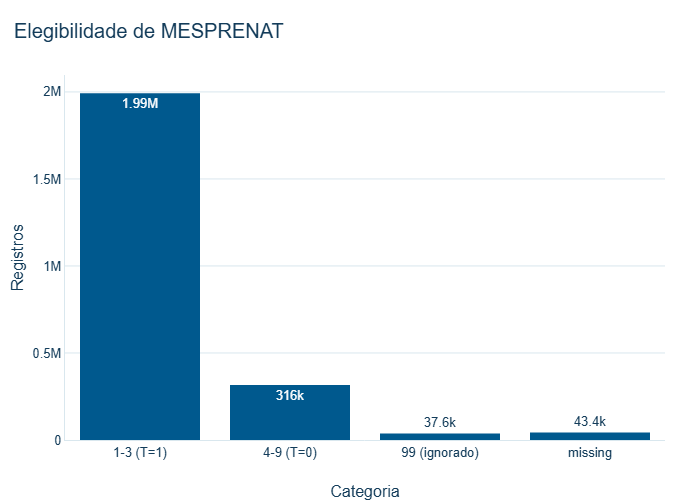

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_tratamento.html


In [2]:
tratamento = pd.DataFrame(amostra["tratamento"])
display(tratamento)
fig_t = px.bar(
    tratamento, x="categoria_mesprenat", y="n",
    labels={"categoria_mesprenat": "Categoria", "n": "Registros"},
    text_auto=".3s",
)
fig_t.update_traces(marker_color=CORES_IPT["AZUL_PRINCIPAL"])
aplicar_tema_ipt(fig_t, "Elegibilidade de MESPRENAT")
fig_t.show()
salvar_figura(fig_t, "fase1_tratamento.png")


Regra reproduzível: `T=1` para meses 1–3; `T=0` para meses 4–9; demais códigos são inelegíveis. Ausência de informação não é ausência de pré-natal.

## 5. Qualidade de Y

O desfecho é peso ao nascer abaixo de 2.500 g. A regra principal P1 restringe pesos a 500–6.000 g; P0, todo peso numérico positivo, permanece como sensibilidade.


,regra,n_valido,n_excluido,n_baixo_peso,prevalencia_baixo_peso_pct
0,P0_peso_positivo,2389104,221,226375,9.475310
1,P1_500_a_6000g,2385318,4007,222648,9.334101


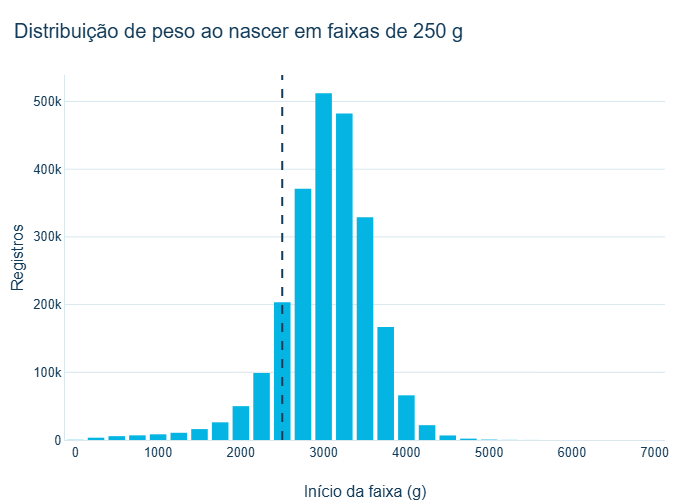

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_peso.html


In [3]:
peso = pd.DataFrame(amostra["outcome_peso"])
display(peso)
dist_peso = pd.read_csv(raiz / "outputs/tables/distribuicao_peso_250g.csv")
fig_peso = px.bar(
    dist_peso, x="inicio_faixa_g", y="n",
    labels={"inicio_faixa_g": "Início da faixa (g)", "n": "Registros"},
)
fig_peso.update_traces(marker_color=CORES_IPT["CIANO"])
fig_peso.add_vline(x=2500, line_dash="dash", line_color=CORES_IPT["AZUL_ESCURO"])
aplicar_tema_ipt(fig_peso, "Distribuição de peso ao nascer em faixas de 250 g")
fig_peso.show()
salvar_figura(fig_peso, "fase1_peso.png")


## 6. Gestação única versus múltipla

,tipo_gravidez,n_total,n_y_valido_p1,baixo_peso_pct,n_t_valido,t1_pct
0,1_unica,2333574,2329966,8.081491,2254839,86.253564
1,2_dupla,53468,53107,62.686651,51843,88.904963
2,3_tripla_ou_mais,978,959,95.203337,942,90.445860
3,9_ignorada,61,58,22.413793,21,61.904762
4,missing,1244,1228,10.993485,743,77.119785


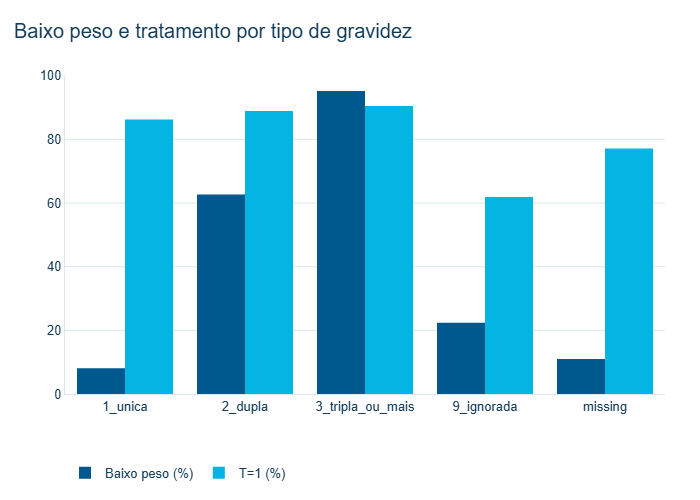

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_gravidez.html


In [4]:
gravidez = pd.DataFrame(amostra["gravidez"])
display(gravidez)
fig_g = go.Figure()
fig_g.add_bar(x=gravidez["tipo_gravidez"], y=gravidez["baixo_peso_pct"], name="Baixo peso (%)")
fig_g.add_bar(x=gravidez["tipo_gravidez"], y=gravidez["t1_pct"], name="T=1 (%)")
fig_g.update_layout(barmode="group")
aplicar_tema_ipt(fig_g, "Baixo peso e tratamento por tipo de gravidez")
fig_g.show()
salvar_figura(fig_g, "fase1_gravidez.png")


Gestações múltiplas têm risco de baixo peso radicalmente distinto e uma gravidez pode gerar mais de um registro. A amostra principal fica restrita a gestação única; todas as gestações válidas permanecem como sensibilidade.

## 7. Covariáveis e temporalidade

Conjunto principal parcimonioso:

1. idade materna;
2. escolaridade materna;
3. raça/cor materna;
4. situação conjugal;
5. paridade;
6. histórico de perdas fetais;
7. UF de residência.

`IDADEPAI` e `SERIESCMAE` ficam fora por missing elevado. `CODOCUPMAE` permanece duvidosa devido à temporalidade/qualidade. Variáveis gestacionais, do parto e neonatais são proibidas no propensity principal.

## 8. DAG

O DAG de trabalho está em `docs/methodology/DAG_INICIAL.md`. Ele separa causas prévias de mediadores gestacionais e impede ajuste pós-tratamento.


## 9. Missing no conjunto X

,variavel,n_missing,pct_total,pct_t1,pct_t0,pct_y1,pct_y0
0,QTDFILMORT,42268,1.877268,1.841924,2.099023,1.418775,1.916568
1,RACACORMAE,28150,1.250239,1.239055,1.320410,1.319202,1.244327
2,ESTCIVMAE,13758,0.611040,0.585259,0.772797,0.583937,0.613364
3,ESCMAE2010,10756,0.477711,0.456632,0.609967,0.399980,0.484374
4,IDADEMAE,32,0.001421,0.000978,0.004200,0.001125,0.001447
5,PARIDADE,0,0.000000,0.000000,0.000000,0.000000,0.000000
6,CODMUNRES,0,0.000000,0.000000,0.000000,0.000000,0.000000


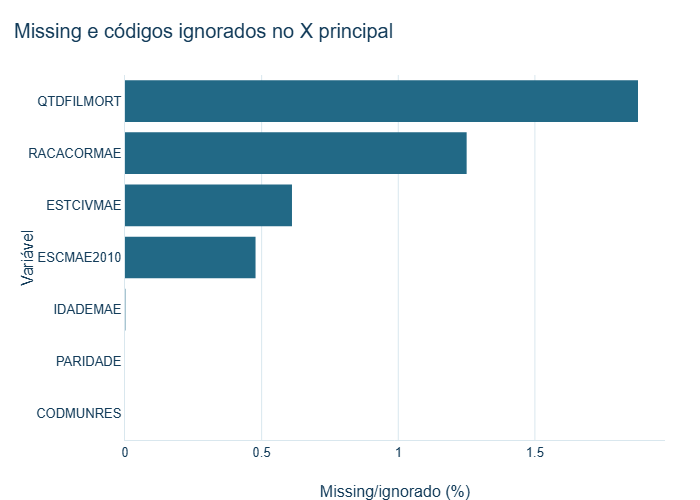

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_missing_x.html


In [5]:
missing = pd.DataFrame(amostra["missing_x_principal"])
display(missing[["variavel", "n_missing", "pct_total", "pct_t1", "pct_t0", "pct_y1", "pct_y0"]])
fig_m = px.bar(
    missing.sort_values("pct_total"), x="pct_total", y="variavel", orientation="h",
    labels={"pct_total": "Missing/ignorado (%)", "variavel": "Variável"},
)
fig_m.update_traces(marker_color=CORES_IPT["AZUL_MEDIO"])
aplicar_tema_ipt(fig_m, "Missing e códigos ignorados no X principal")
fig_m.update_yaxes(automargin=True)
fig_m.show()
salvar_figura(fig_m, "fase1_missing_x.png")


Estratégia: categorias explícitas `IGNORADO` para X categóricas; mediana mais indicador de missing para idade no pipeline. Não há MICE nem exclusão complete-case.

## 10. Fluxo da amostra


,etapa,n_antes,n_excluido,motivo,n_restante,percentual_base_inicial
0,A0,2389325,81079,T conhecido e PESO numerico positivo,2308246,96.606615
1,A1,2308246,3471,A0 + 500 g <= PESO <= 6.000 g,2304775,96.461344
2,A2,2304775,53205,A1 + gestacao unica (GRAVIDEZ=1),2251570,94.234564
3,A3,2251570,0,A2 + X principal preparado; missing tratado no...,2251570,94.234564


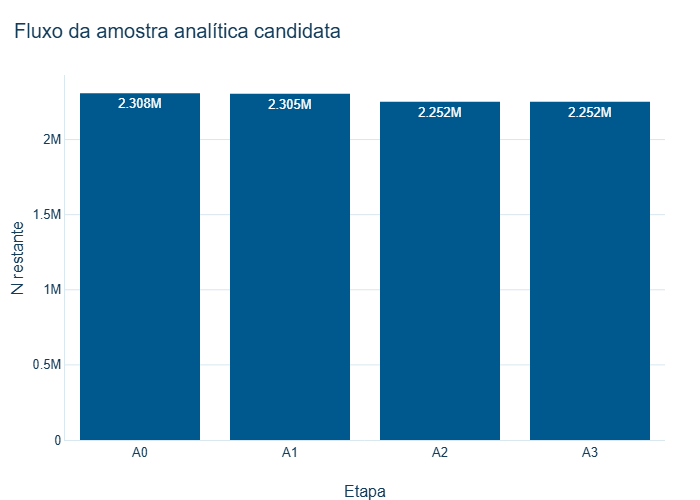

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_fluxo_amostra.html


In [6]:
fluxo = pd.DataFrame(amostra["fluxo_amostra"])
display(fluxo)
fig_f = px.bar(
    fluxo, x="etapa", y="n_restante", text_auto=".4s",
    labels={"etapa": "Etapa", "n_restante": "N restante"},
)
fig_f.update_traces(marker_color=CORES_IPT["AZUL_PRINCIPAL"])
fig_f.update_yaxes(rangemode="tozero")
aplicar_tema_ipt(fig_f, "Fluxo da amostra analítica candidata")
fig_f.show()
salvar_figura(fig_f, "fase1_fluxo_amostra.png")


## 11. Perfil T=1 versus T=0

In [7]:
perfil_t = pd.DataFrame(amostra["perfil_tratamento_amostra_principal"])
display(perfil_t)


,tratamento,n,percentual,idade_media,idade_dp,idade_mediana,baixo_peso_pct_descritivo
0,1,1942045,86.252926,27.951621,6.596390,28.0,7.699152
1,0,309525,13.747074,26.405248,6.999538,26.0,9.123011


A prevalência bruta de baixo peso nesta tabela é somente descritiva. Ela não é efeito causal nem será usada para selecionar o propensity.

## 12. SMD antes de qualquer ajuste


,variavel,tipo,media_t1,media_t0,smd,smd_abs,nivel_pior_smd,proporcao_t1,proporcao_t0
0,SITUACAO_CONJUGAL,categorica_pior_nivel,NaN,NaN,0.375217,0.375217,2,0.338302,0.177016
1,ESCOLARIDADE_MAE,categorica_pior_nivel,NaN,NaN,0.330586,0.330586,5,0.212850,0.095126
2,RACA_COR_MAE,categorica_pior_nivel,NaN,NaN,0.230975,0.230975,1,0.348685,0.243912
3,IDADEMAE_NUM,numerica,27.951621,26.405248,0.227376,0.227376,NaN,NaN,NaN
4,PARIDADE_CAT,categorica_pior_nivel,NaN,NaN,0.154442,0.154442,0,0.379181,0.306101
5,UF_RESIDENCIA,categorica_pior_nivel,NaN,NaN,-0.152040,0.152040,15,0.043124,0.079493
6,PERDAS_FETAIS_CAT,categorica_pior_nivel,NaN,NaN,0.033503,0.033503,1,0.169384,0.157005


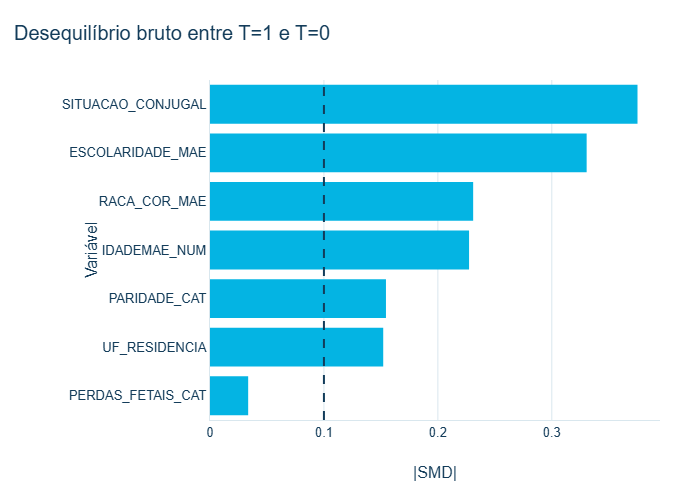

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_smd_bruto.html


In [8]:
balanceamento = pd.DataFrame(amostra["balanceamento_bruto"])
display(balanceamento)
fig_smd = px.bar(
    balanceamento.sort_values("smd_abs"), x="smd_abs", y="variavel", orientation="h",
    labels={"smd_abs": "|SMD|", "variavel": "Variável"},
)
fig_smd.update_traces(marker_color=CORES_IPT["CIANO"])
fig_smd.add_vline(x=0.1, line_dash="dash", line_color=CORES_IPT["AZUL_ESCURO"])
aplicar_tema_ipt(fig_smd, "Desequilíbrio bruto entre T=1 e T=0")
fig_smd.update_layout(margin=dict(l=210, r=40, t=80, b=80))
fig_smd.update_yaxes(automargin=True)
fig_smd.show()
salvar_figura(fig_smd, "fase1_smd_bruto.png")


O SMD é o diagnóstico central; p-valores não são usados. Para categóricas, reporta-se o nível com maior SMD absoluto.

## 13. Propensity score diagnóstico

Modelo planejado: regressão logística L2, one-hot sparse, imputação simples explícita e 5 folds estratificados out-of-fold. O pipeline recebe apenas X pré-tratamento e possui guarda programática contra leakage. AUC, quando disponível, descreve separação de T; AUC alta não implica melhor validade causal.


In [9]:
display(Markdown(f"**Status do propensity:** `{overlap['status']}`"))
if overlap["status"] == "CONCLUIDO":
    display(pd.DataFrame(overlap["trimming_diagnostico"]))
    print("Métricas:", overlap["metodo"])
else:
    print(overlap.get("erro", overlap.get("motivo")))
    print("Pendências:", overlap.get("diagnosticos_pendentes", []))


**Status do propensity:** `CONCLUIDO`

,regra,limite_inferior,limite_superior,n_total,n_mantido,n_excluido,n_tratado_mantido,n_controle_mantido,n_tratado_excluido,n_controle_excluido
0,sem_trimming,0.00,1.00,2251570,2251570,0,1942045,309525,0,0
1,0.01_0.99,0.01,0.99,2251570,2251570,0,1942045,309525,0,0
2,0.05_0.95,0.05,0.95,2251570,2104020,147550,1801166,302854,140879,6671


Métricas: {'modelo': 'regressao logistica L2', 'previsoes': 'out-of-fold estratificadas', 'semente': 20240925, 'covariaveis': ['IDADEMAE_NUM', 'ESCOLARIDADE_MAE', 'RACA_COR_MAE', 'SITUACAO_CONJUGAL', 'PARIDADE_CAT', 'PERDAS_FETAIS_CAT', 'UF_RESIDENCIA'], 'outcome_usado': False, 'n_folds': 5, 'auc_oof': 0.6628730972846343, 'convergencia': [{'fold': 1, 'n_iter': 54, 'convergiu': True}, {'fold': 2, 'n_iter': 58, 'convergiu': True}, {'fold': 3, 'n_iter': 49, 'convergiu': True}, {'fold': 4, 'n_iter': 51, 'convergiu': True}, {'fold': 5, 'n_iter': 57, 'convergiu': True}], 'solver': 'lbfgs', 'max_iter': 500, 'tol': 1e-05}


## 14. Overlap

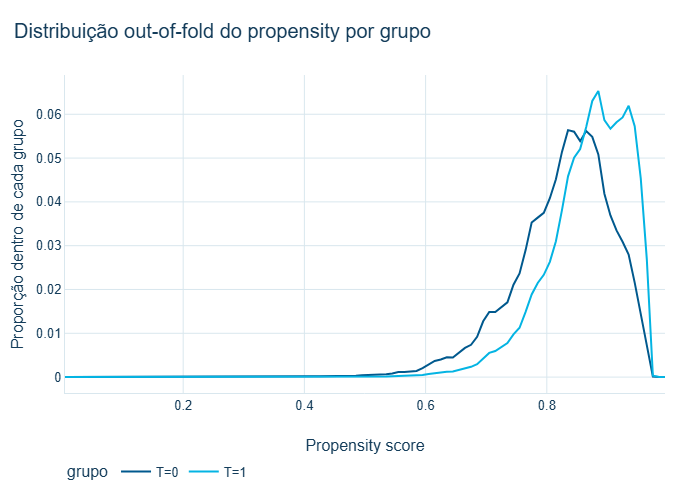

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_overlap_propensity.html


In [10]:
hist_path = raiz / "outputs/tables/histograma_propensity.csv"
if overlap["status"] == "CONCLUIDO" and hist_path.exists():
    hist = pd.read_csv(hist_path)
    hist["centro"] = (hist["limite_inferior"] + hist["limite_superior"]) / 2
    hist["proporcao"] = hist["n"] / hist.groupby("grupo")["n"].transform("sum")
    fig_o = px.line(hist, x="centro", y="proporcao", color="grupo",
                    labels={"centro": "Propensity score", "proporcao": "Proporção dentro de cada grupo"})
    aplicar_tema_ipt(fig_o, "Distribuição out-of-fold do propensity por grupo")
    fig_o.show()
    salvar_figura(fig_o, "fase1_overlap_propensity.png")
else:
    display(Markdown("O overlap por propensity não pode ser interpretado até a dependência declarada ser instalada e o pipeline OOF ser executado."))


## 15. Positividade por perfis

,perfil,categoria,n,n_t1,n_t0,proporcao_t1,flag_quase_deterministico,flag_celula_pequena
0,UF_RESIDENCIA,11,18782,15823,2959,0.842456,False,False
1,UF_RESIDENCIA,12,11862,8352,3510,0.704097,False,False
2,UF_RESIDENCIA,13,62614,46367,16247,0.740521,False,False
3,UF_RESIDENCIA,14,11105,7653,3452,0.689149,False,False
4,UF_RESIDENCIA,15,108354,83749,24605,0.772920,False,False
5,UF_RESIDENCIA,16,11746,8600,3146,0.732164,False,False
6,UF_RESIDENCIA,17,21119,18123,2996,0.858137,False,False
7,UF_RESIDENCIA,21,86044,71826,14218,0.834759,False,False
8,UF_RESIDENCIA,22,36612,30625,5987,0.836474,False,False
9,UF_RESIDENCIA,23,95379,82897,12482,0.869133,False,False


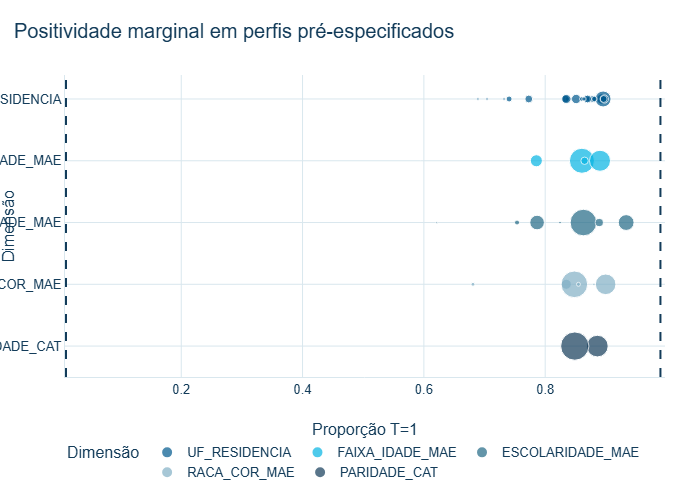

Figura interativa salva: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\outputs\figures\fase1_positividade_perfis.html


In [11]:
positividade = pd.DataFrame(amostra["positividade_perfis"])
display(positividade)
fig_pos = px.scatter(
    positividade, x="proporcao_t1", y="perfil", size="n", color="perfil",
    hover_data=["categoria", "n_t1", "n_t0"],
    labels={"proporcao_t1": "Proporção T=1", "perfil": "Dimensão"},
)
fig_pos.add_vline(x=0.01, line_dash="dash", line_color=CORES_IPT["AZUL_ESCURO"])
fig_pos.add_vline(x=0.99, line_dash="dash", line_color=CORES_IPT["AZUL_ESCURO"])
aplicar_tema_ipt(fig_pos, "Positividade marginal em perfis pré-especificados")
fig_pos.show()
salvar_figura(fig_pos, "fase1_positividade_perfis.png")


As margens simples não substituem o suporte multivariado do propensity. Elas apenas procuram bolsões óbvios de tratamento quase determinístico.

## 16. Sensibilidades de elegibilidade

- Peso: P1 (500–6.000 g) principal; P0 (>0 g) sensibilidade.
- Gravidez: única principal; todas as gestações válidas como sensibilidade.
- Ausência de pré-natal: `CONSPRENAT=0` descrito separadamente; não incorporado automaticamente a T=0.
- Trimming: 0,01–0,99 e 0,05–0,95 serão apenas diagnósticos, nunca regras automáticas nesta fase.

## 17. Gate da Fase 1


In [12]:
if overlap["status"] == "CONCLUIDO":
    gate = "PRONTO_COM_RESSALVAS"
    justificativa = "Amostra e contrato são coerentes; overlap foi quantificado, mas confundimento não observado permanece uma hipótese forte."
else:
    gate = "NAO_PRONTO"
    justificativa = "A amostra está definida, porém o diagnóstico multivariado de overlap ainda não foi executado."
display(Markdown(f"### {gate}\n\n{justificativa}\n\n**EFEITO_CAUSAL_ESTIMADO = NÃO**"))


### PRONTO_COM_RESSALVAS

Amostra e contrato são coerentes; overlap foi quantificado, mas confundimento não observado permanece uma hipótese forte.

**EFEITO_CAUSAL_ESTIMADO = NÃO**